# LSTM on MediaPipe keypoints — ASL-only vs SGSL-only

Trains **two separate models** on sequences built from **`03_mediapipe_pose_hands_videos.ipynb`** outputs:

| Experiment | Training data | Classes |
|------------|----------------|---------|
| **ASL only** | `Videos/ASL_60_pose_hands_keypoints` (or `ASL_pose_hands_keypoints`) | ASL gloss folder names |
| **SGSL only** | `Videos/SGSL_pose_hands_keypoints` | SGSL place folders |

Each frame is **`frame_XXXXXX.npy`** shaped **`(75, 5)`** → flattened to **`375`** floats per timestep. Sequences are padded / truncated to **`SEQ_LEN`** (default **60**).

**Metrics:** stratified **80 / 10 / 10** train/val/test (falls back to random split if stratification is impossible); test **accuracy** reported for each corpus.

**Install packages once** (Terminal or your venv), **then start Jupyter**. On **macOS ARM**, TensorFlow **2.20+** has been observed to **abort on import** (`mutex lock failed`) when mixed with certain **protobuf/pyarrow** builds — this notebook pins **`tensorflow>=2.15,<2.20`** (latest **2.19.x**) in the next cell to avoid that.

Avoid upgrading TensorFlow mid-session — it can **restart the kernel**.

By default the notebook sets **`FORCE_TF_CPU_ONLY = True`** (Metal/GPU backends sometimes segfault Jupyter). After everything runs reliably, try **`False`** for faster training if your GPU stack is stable.

If training still stresses memory, keep **`BATCH_SIZE = 8`**. For a short smoke run (~40 epochs), run with **`SIGNLANG_QUICK_RUN=1`** in the environment before starting Jupyter (see training cell).
```bash
pip install "tensorflow>=2.15,<2.20" "scikit-learn>=1.3" "numpy>=1.26,<2"
```


In [21]:
# Pin TF <2.20 on macOS ARM — TF 2.20+ can abort on import (protobuf / pyarrow clashes).
%pip install -q "tensorflow>=2.15,<2.20" "scikit-learn>=1.3" "numpy>=1.26,<2"  "matplotlib"


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [13]:
import importlib.util
import sys

def _missing(pkgs: list[tuple[str, str]]) -> list[str]:
    lines = []
    for mod_name, pip_line in pkgs:
        if importlib.util.find_spec(mod_name) is None:
            lines.append(f"  - {pip_line}")
    return lines

_hints = _missing(
    [
        ("numpy", 'pip install "numpy>=1.26,<2"'),
        ("sklearn", 'pip install "scikit-learn>=1.3"'),
        ("tensorflow", 'pip install "tensorflow>=2.15,<2.20"'),
    ]
)
if _hints:
    print(
        "Missing dependencies. Install in Terminal (same Python as Jupyter), then restart the kernel:\n"
        + "\n".join(_hints)
        + "\n\nIf imports still abort on macOS ARM, ensure TF is pinned to <2.20 (see first pip cell).",
        file=sys.stderr,
    )
    raise ImportError("Install dependencies (see messages above), restart Jupyter, then re-run.")

print("Dependencies OK.")


Dependencies OK.


In [14]:
from __future__ import annotations

import gc
import os
import warnings
from pathlib import Path

import numpy as np

# Must be set before importing TensorFlow (Metal/CUDA backend stability in Jupyter).
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
os.environ.setdefault("TF_ENABLE_ONEDNN_OPTS", "0")
os.environ.setdefault("TF_NUM_INTEROP_THREADS", "4")
os.environ.setdefault("TF_NUM_INTRAOP_THREADS", "4")

# Apple Silicon Metal / some GPU stacks segfault the Jupyter kernel — CPU-only is slower but stable.
FORCE_TF_CPU_ONLY = True

import tensorflow as tf
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore", category=UserWarning)

if FORCE_TF_CPU_ONLY:
    try:
        tf.config.set_visible_devices([], "GPU")
    except Exception:
        try:
            tf.config.experimental.set_visible_devices([], "GPU")
        except Exception:
            pass

try:
    for _gpu in tf.config.list_physical_devices("GPU"):
        tf.config.experimental.set_memory_growth(_gpu, True)
except Exception:
    pass

PROJECT_ROOT = Path(".").resolve()

# Match `03_*` keypoints output layout
_used_asl_60 = (PROJECT_ROOT / "Videos" / "ASL_60").is_dir()
ASL_KP_ROOT = (
    PROJECT_ROOT / "Videos" / "ASL_60_pose_hands_keypoints"
    if _used_asl_60
    else PROJECT_ROOT / "Videos" / "ASL_pose_hands_keypoints"
)
SGSL_KP_ROOT = PROJECT_ROOT / "Videos" / "SGSL_pose_hands_keypoints"

SEQ_LEN = 60
RANDOM_STATE = 42
ARTIFACTS = PROJECT_ROOT / "artifacts_lstm_asl_sgsl"
ARTIFACTS.mkdir(parents=True, exist_ok=True)

# Training / model (smaller batch reduces RAM spikes during LSTM + BN)
# Export SIGNLANG_QUICK_RUN=1 for a faster smoke run (~40 epochs max).
_QUICK = os.environ.get("SIGNLANG_QUICK_RUN", "").lower() in ("1", "true", "yes")
MAX_EPOCHS = 40 if _QUICK else 500
BATCH_SIZE = 16


In [15]:
def _sorted_clip_dirs(class_dir: Path) -> list[Path]:
    out = []
    for p in class_dir.iterdir():
        if not p.is_dir() or p.name.startswith("."):
            continue
        try:
            out.append((int(p.name), p))
        except ValueError:
            out.append((p.name, p))
    out.sort(key=lambda t: t[0])
    return [p for _, p in out]


def load_flat_clip(clip_dir: Path, seq_len: int) -> np.ndarray | None:
    """Return float32 array (seq_len, F) or None if unusable."""
    files = sorted(clip_dir.glob("frame_*.npy"))
    if not files:
        return None

    frames: list[np.ndarray] = []
    feat_dim: int | None = None

    for f in files[:seq_len]:
        a = np.load(f).astype(np.float32, copy=False)
        if a.ndim == 2 and a.shape[1] == 5:
            v = np.nan_to_num(a.reshape(-1), nan=0.0, posinf=0.0, neginf=0.0)
        elif a.ndim == 1:
            v = np.nan_to_num(a, nan=0.0, posinf=0.0, neginf=0.0)
        else:
            return None

        if feat_dim is None:
            feat_dim = int(v.shape[0])
        elif int(v.shape[0]) != feat_dim:
            return None

        frames.append(v.astype(np.float32, copy=False))

    if feat_dim is None:
        return None

    if len(frames) < seq_len:
        pad = np.zeros((seq_len - len(frames), feat_dim), dtype=np.float32)
        frames.extend(list(pad))

    seq = np.stack(frames[:seq_len], axis=0).astype(np.float32)
    return seq


def collect_from_root(key_root: Path, label_fn) -> tuple[list[np.ndarray], list[str]]:
    """label_fn(class_name: str) -> str label for this clip."""
    X_list: list[np.ndarray] = []
    y_list: list[str] = []

    if not key_root.is_dir():
        return X_list, y_list

    class_dirs = sorted(
        [p for p in key_root.iterdir() if p.is_dir() and not p.name.startswith(".")],
        key=lambda p: p.name.lower(),
    )

    for cdir in class_dirs:
        lbl = label_fn(cdir.name)
        for clip in _sorted_clip_dirs(cdir):
            seq = load_flat_clip(clip, SEQ_LEN)
            if seq is None:
                continue
            if not np.isfinite(seq).all():
                continue
            X_list.append(seq)
            y_list.append(lbl)

    return X_list, y_list


def to_tensors(
    X_list: list[np.ndarray], y_labels: list[str]
) -> tuple[np.ndarray, np.ndarray, np.ndarray, LabelEncoder]:
    if not X_list:
        raise ValueError("No sequences loaded — run `03_*` keypoint export first.")
    X = np.stack(X_list, axis=0).astype(np.float32)
    le = LabelEncoder()
    y_int = le.fit_transform(y_labels)
    y_oh = tf.keras.utils.to_categorical(y_int, num_classes=len(le.classes_)).astype(np.float32)
    return X, y_oh, y_int, le


def _train_test_maybe_stratify(*arrays, test_size: float, stratify=None):
    kwargs = {"test_size": test_size, "random_state": RANDOM_STATE}
    try:
        return train_test_split(*arrays, stratify=stratify, **kwargs)
    except ValueError:
        # e.g. too few samples per class after filtering
        return train_test_split(*arrays, **kwargs)


def stratified_three_way(X, y_oh, y_int):
    (
        X_train,
        X_tmp,
        y_train,
        y_tmp,
        yi_train,
        yi_tmp,
    ) = _train_test_maybe_stratify(X, y_oh, y_int, test_size=0.20, stratify=y_int)
    (
        X_val,
        X_test,
        y_val,
        y_test,
        yi_val,
        yi_test,
    ) = _train_test_maybe_stratify(
        X_tmp, y_tmp, yi_tmp, test_size=0.50, stratify=yi_tmp
    )
    return (X_train, y_train, yi_train), (X_val, y_val, yi_val), (X_test, y_test, yi_test)


def sample_weights_from_y(y_train_oh: np.ndarray, num_classes: int) -> np.ndarray:
    """Inverse-frequency sample weights over training labels (helps rare classes).

    SGSL typically has fewer clips per place than ASL per gloss; weights partly offset imbalance.
    """
    yi = np.argmax(y_train_oh, axis=1)
    counts = np.bincount(yi, minlength=num_classes).astype(np.float64)
    inv_freq = (counts.sum() / (counts + 1e-12)) / num_classes
    return inv_freq[yi].astype(np.float32)



def build_lstm(
    seq_len: int,
    feat_dim: int,
    num_classes: int,
    *,
    learning_rate: float = 1e-3,
    input_gaussian_noise_std: float = 0.0,
    dense_l2: float | None = None,
) -> tf.keras.Model:
    dense_reg = (
        tf.keras.regularizers.l2(dense_l2) if dense_l2 is not None else None
    )
    inputs = tf.keras.Input(shape=(seq_len, feat_dim))
    x = inputs
    if input_gaussian_noise_std > 0:
        x = tf.keras.layers.GaussianNoise(input_gaussian_noise_std)(x)
    x = tf.keras.layers.LSTM(128, return_sequences=True, use_cudnn=False)(x)
    x = tf.keras.layers.Dropout(0.30)(x)
    x = tf.keras.layers.LSTM(64, return_sequences=False, use_cudnn=False)(x)
    x = tf.keras.layers.Dropout(0.30)(x)
    x = tf.keras.layers.Dense(128, activation="relu", kernel_regularizer=dense_reg)(
        x
    )
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.30)(x)
    outputs = tf.keras.layers.Dense(
        num_classes, activation="softmax", kernel_regularizer=dense_reg
    )(x)
    model = tf.keras.Model(inputs, outputs)

    metrics = ["accuracy"]
    k_top = min(3, num_classes)
    if k_top >= 2:
        metrics.append(
            tf.keras.metrics.TopKCategoricalAccuracy(k=k_top, name=f"top{k_top}_acc")
        )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate),
        loss="categorical_crossentropy",
        metrics=metrics,
    )
    return model


def train_one_run(
    name: str,
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    yi_test,
    *,
    learning_rate: float | None = None,
    early_stopping_patience: int | None = None,
    input_gaussian_noise_std: float | None = None,
    dense_l2: float | None = None,
):
    """Train with NumPy arrays (avoids tf.data embedding huge constants — common RAM/kernel crash).

    Corpus-specific defaults: **SGSL_only** uses a lower LR, higher early-stop patience,
    Gaussian noise after the input (train-time only), and L2 on dense layers; **ASL_only**
    keeps the prior ASL-oriented defaults.

    Passing keyword args overrides defaults for either run name.
    """
    if name == "SGSL_only":
        base_kw = dict(
            learning_rate=5e-4,
            early_stopping_patience=20,
            input_gaussian_noise_std=0.02,
            dense_l2=1e-4,
        )
    else:
        base_kw = dict(
            learning_rate=1e-3,
            early_stopping_patience=15,
            input_gaussian_noise_std=0.0,
            dense_l2=None,
        )
    kw = dict(base_kw)
    if learning_rate is not None:
        kw["learning_rate"] = learning_rate
    if early_stopping_patience is not None:
        kw["early_stopping_patience"] = early_stopping_patience
    if input_gaussian_noise_std is not None:
        kw["input_gaussian_noise_std"] = input_gaussian_noise_std
    if dense_l2 is not None:
        kw["dense_l2"] = dense_l2

    tf.keras.backend.clear_session()
    gc.collect()

    num_classes = y_train.shape[1]
    seq_len = X_train.shape[1]
    feat_dim = X_train.shape[2]

    sw = sample_weights_from_y(y_train, num_classes)

    model = build_lstm(
        seq_len,
        feat_dim,
        num_classes,
        learning_rate=float(kw["learning_rate"]),
        input_gaussian_noise_std=float(kw["input_gaussian_noise_std"]),
        dense_l2=kw["dense_l2"],
    )

    ckpt = ARTIFACTS / f"lstm_{name}.keras"
    cbs = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=int(kw["early_stopping_patience"]),
            restore_best_weights=True,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=8, min_lr=1e-5
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=str(ckpt),
            monitor="val_loss",
            save_best_only=True,
        ),
    ]

    model.fit(
        X_train,
        y_train,
        sample_weight=sw,
        validation_data=(X_val, y_val),
        batch_size=BATCH_SIZE,
        epochs=MAX_EPOCHS,
        callbacks=cbs,
        shuffle=True,
        verbose=1,
    )

    # In-memory weights match EarlyStopping best val_loss (same metric as checkpoint).
    probs = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)
    pred = np.argmax(probs, axis=1)

    del probs
    del model
    tf.keras.backend.clear_session()
    gc.collect()

    out = {
        "name": name,
        "test_accuracy": float(accuracy_score(yi_test, pred)),
        "n_classes": int(num_classes),
        "n_test": int(len(X_test)),
    }

    print("\n===", name, "===")
    for k in sorted(out.keys()):
        if k != "name":
            print(f"  {k}: {out[k]}")

    return out


In [16]:
results: list[dict] = []

# ----- ASL only -----
print("ASL keypoints root:", ASL_KP_ROOT)
X_a, y_a = collect_from_root(ASL_KP_ROOT, lambda g: g)
if len(X_a) == 0:
    print("[SKIP] No ASL keypoint sequences — export keypoints with `03_*`.")
else:
    X, y_oh, y_int, le_asl = to_tensors(X_a, y_a)
    (tr, va, te) = stratified_three_way(X, y_oh, y_int)
    (X_train, y_train, yi_train), (X_val, y_val, yi_val), (X_test, y_test, yi_test) = (
        tr,
        va,
        te,
    )
    results.append(
        train_one_run("ASL_only", X_train, y_train, X_val, y_val, X_test, y_test, yi_test)
    )
    del X, y_oh, y_int, X_train, X_val, X_test, y_train, y_val, y_test, yi_train, yi_val, yi_test
    gc.collect()

# ----- SGSL only -----
print("SGSL keypoints root:", SGSL_KP_ROOT)
X_s, y_s = collect_from_root(SGSL_KP_ROOT, lambda p: p)
if len(X_s) == 0:
    print("[SKIP] No SGSL keypoint sequences.")
else:
    X, y_oh, y_int, le_sgsl = to_tensors(X_s, y_s)
    (tr, va, te) = stratified_three_way(X, y_oh, y_int)
    (X_train, y_train, yi_train), (X_val, y_val, yi_val), (X_test, y_test, yi_test) = (
        tr,
        va,
        te,
    )
    results.append(
        train_one_run("SGSL_only", X_train, y_train, X_val, y_val, X_test, y_test, yi_test)
    )
    del X, y_oh, y_int, X_train, X_val, X_test, y_train, y_val, y_test, yi_train, yi_val, yi_test
    gc.collect()


ASL keypoints root: /Users/sritampatnaik/Masters/NUS-ISS Sritam/NUS-ISS Sem 3/Sign-Lang/Videos/ASL_60_pose_hands_keypoints
Epoch 1/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.1944 - loss: 2.3444 - top3_acc: 0.5556 - val_accuracy: 0.1667 - val_loss: 1.7841 - val_top3_acc: 0.5000 - learning_rate: 0.0010
Epoch 2/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.2639 - loss: 2.0219 - top3_acc: 0.5833 - val_accuracy: 0.3333 - val_loss: 1.7472 - val_top3_acc: 0.5556 - learning_rate: 0.0010
Epoch 3/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.3194 - loss: 1.9164 - top3_acc: 0.6944 - val_accuracy: 0.3333 - val_loss: 1.6511 - val_top3_acc: 0.7222 - learning_rate: 0.0010
Epoch 4/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.3611 - loss: 1.6922 - top3_acc: 0.7222 - val_accuracy: 0.3333 - val_loss: 1.5358 - val_top3_acc: 0.8333 - learning_rate: 0.0010
Epoch 5/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.3542 - loss: 1.6200 - top3_acc: 0.7778 - val_

In [17]:
# Summary (no pandas dependency) — one row per corpus run (ASL_only, SGSL_only).
if not results:
    print("No experiments ran.")
else:
    keys = sorted({k for r in results for k in r})
    header = " | ".join(keys)
    print(header)
    print("-" * len(header))
    for r in results:
        print(" | ".join(str(r.get(k, "")) for k in keys))


n_classes | n_test | name | test_accuracy
-----------------------------------------
6 | 18 | ASL_only | 0.9444444444444444
6 | 18 | SGSL_only | 0.7222222222222222


### Evaluation — train / validation / test (same style as `[OLD] 03_train_lstm_6_classes.ipynb`)

For each corpus, re-load **`artifacts_lstm_asl_sgsl/lstm_<run>.keras`**, rebuild the **same stratified 80/10/10 split** (`RANDOM_STATE`), then for **train**, **val**, and **test**:

- Accuracy and **`classification_report`**
- **Raw** and **row-normalized** confusion matrices saved as **`{run}_{split}_cm.csv`** / **`{run}_{split}_cm_norm.csv`**
- **Normalized** confusion matrix plot saved as **`{run}_{split}_cm.png`**

Run **after** training so checkpoints exist.


=== ASL_ONLY · TRAIN ===
Accuracy: 1.0000
              precision    recall  f1-score   support

      africa     1.0000    1.0000    1.0000        24
   australia     1.0000    1.0000    1.0000        24
        city     1.0000    1.0000    1.0000        24
     college     1.0000    1.0000    1.0000        24
      school     1.0000    1.0000    1.0000        24
       south     1.0000    1.0000    1.0000        24

    accuracy                         1.0000       144
   macro avg     1.0000    1.0000    1.0000       144
weighted avg     1.0000    1.0000    1.0000       144



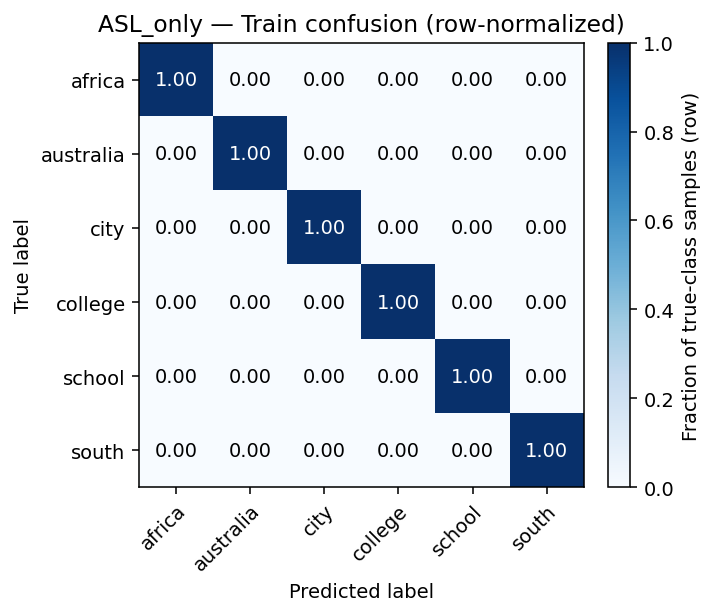


=== ASL_ONLY · VAL ===
Accuracy: 1.0000
              precision    recall  f1-score   support

      africa     1.0000    1.0000    1.0000         3
   australia     1.0000    1.0000    1.0000         3
        city     1.0000    1.0000    1.0000         3
     college     1.0000    1.0000    1.0000         3
      school     1.0000    1.0000    1.0000         3
       south     1.0000    1.0000    1.0000         3

    accuracy                         1.0000        18
   macro avg     1.0000    1.0000    1.0000        18
weighted avg     1.0000    1.0000    1.0000        18



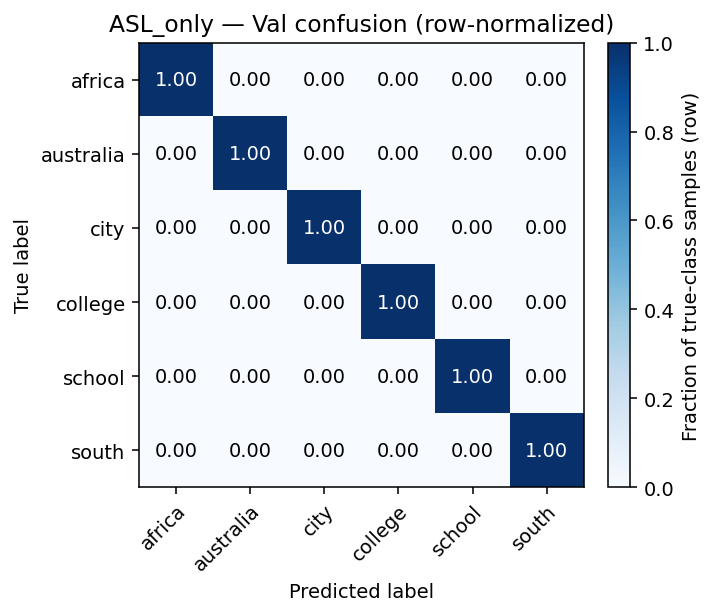


=== ASL_ONLY · TEST ===
Accuracy: 0.9444
              precision    recall  f1-score   support

      africa     1.0000    0.6667    0.8000         3
   australia     1.0000    1.0000    1.0000         3
        city     1.0000    1.0000    1.0000         3
     college     1.0000    1.0000    1.0000         3
      school     1.0000    1.0000    1.0000         3
       south     0.7500    1.0000    0.8571         3

    accuracy                         0.9444        18
   macro avg     0.9583    0.9444    0.9429        18
weighted avg     0.9583    0.9444    0.9429        18



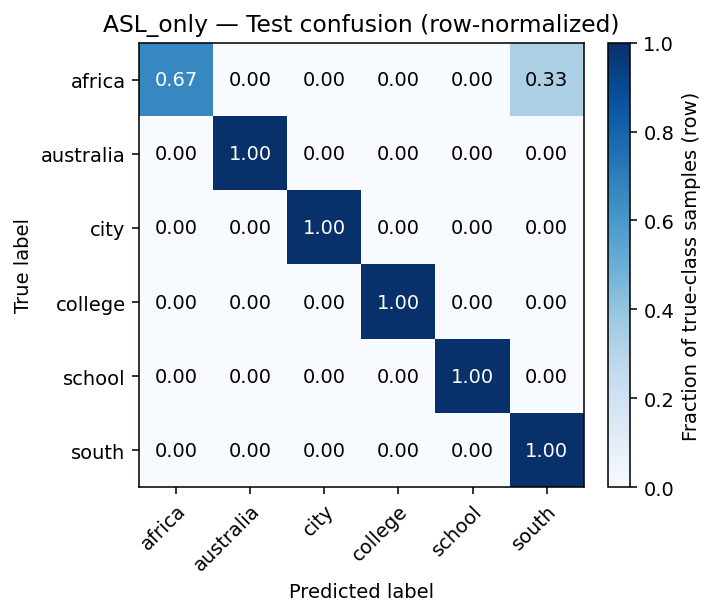


Saved CSV/PNG confusion matrices under: /Users/sritampatnaik/Masters/NUS-ISS Sritam/NUS-ISS Sem 3/Sign-Lang/artifacts_lstm_asl_sgsl

=== SGSL_ONLY · TRAIN ===
Accuracy: 0.8750
              precision    recall  f1-score   support

       Bedok     0.8214    0.9583    0.8846        24
   City Hall     1.0000    1.0000    1.0000        24
    Clementi     0.8148    0.9167    0.8627        24
   Esplanade     1.0000    0.7500    0.8571        24
         MBS     0.8000    1.0000    0.8889        24
     Orchard     0.8824    0.6250    0.7317        24

    accuracy                         0.8750       144
   macro avg     0.8864    0.8750    0.8708       144
weighted avg     0.8864    0.8750    0.8708       144



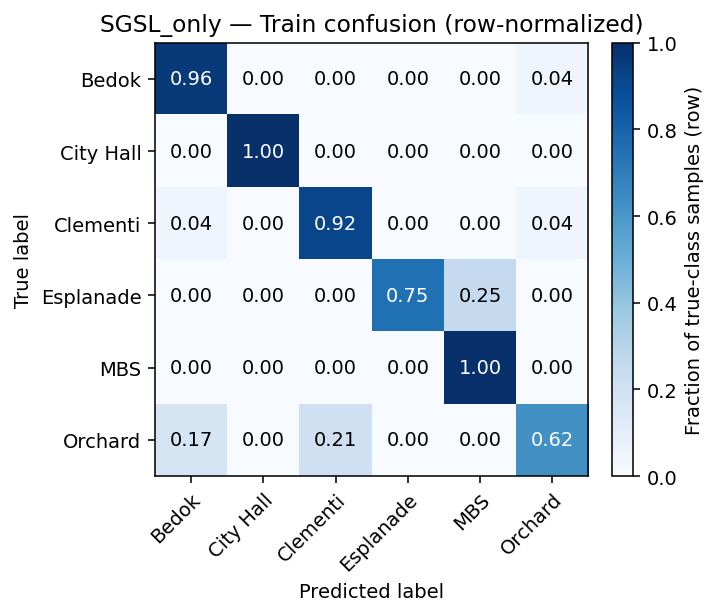


=== SGSL_ONLY · VAL ===
Accuracy: 0.8889
              precision    recall  f1-score   support

       Bedok     1.0000    0.6667    0.8000         3
   City Hall     1.0000    1.0000    1.0000         3
    Clementi     0.7500    1.0000    0.8571         3
   Esplanade     1.0000    0.6667    0.8000         3
         MBS     0.7500    1.0000    0.8571         3
     Orchard     1.0000    1.0000    1.0000         3

    accuracy                         0.8889        18
   macro avg     0.9167    0.8889    0.8857        18
weighted avg     0.9167    0.8889    0.8857        18



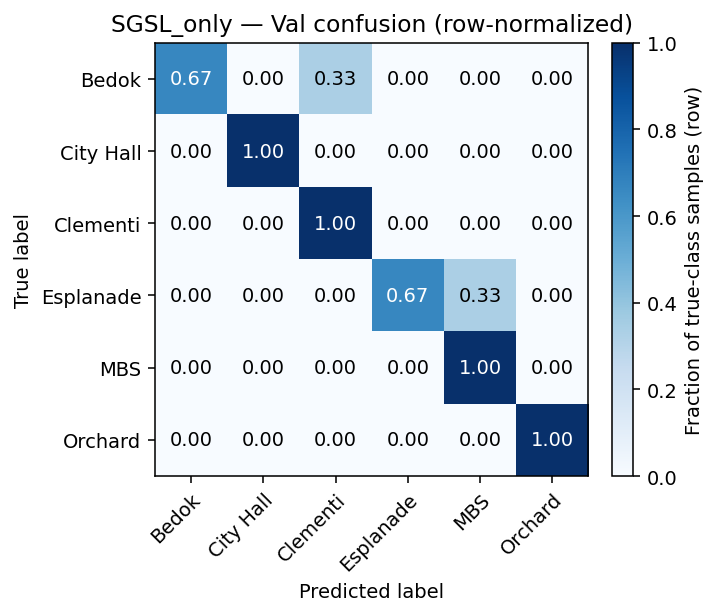


=== SGSL_ONLY · TEST ===
Accuracy: 0.7222
              precision    recall  f1-score   support

       Bedok     0.6667    0.6667    0.6667         3
   City Hall     1.0000    1.0000    1.0000         3
    Clementi     0.3333    0.3333    0.3333         3
   Esplanade     1.0000    1.0000    1.0000         3
         MBS     1.0000    1.0000    1.0000         3
     Orchard     0.3333    0.3333    0.3333         3

    accuracy                         0.7222        18
   macro avg     0.7222    0.7222    0.7222        18
weighted avg     0.7222    0.7222    0.7222        18



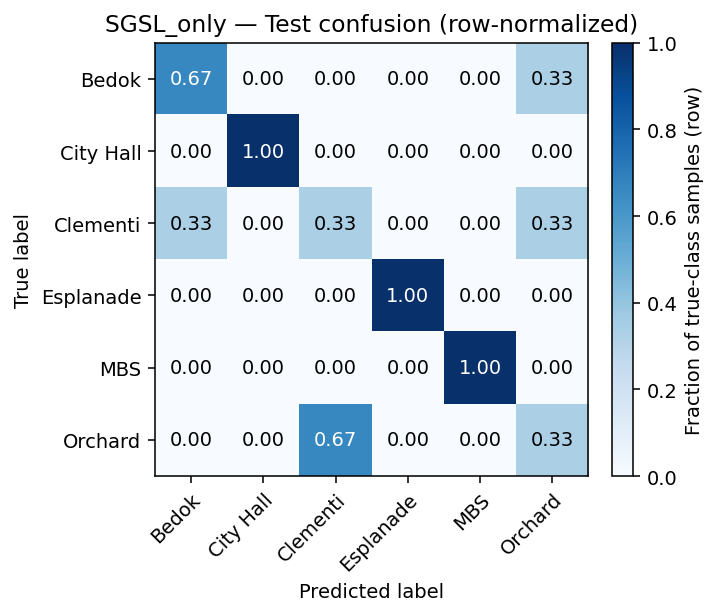


Saved CSV/PNG confusion matrices under: /Users/sritampatnaik/Masters/NUS-ISS Sritam/NUS-ISS Sem 3/Sign-Lang/artifacts_lstm_asl_sgsl


In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


def evaluate_split_old_style(
    model: tf.keras.Model,
    X: np.ndarray,
    y_onehot: np.ndarray,
    *,
    split_name: str,
    corpus_tag: str,
    class_names: list[str],
) -> tuple[float, np.ndarray, np.ndarray]:
    """Matches `[OLD] 03_train_lstm_6_classes.ipynb`: predict, metrics, CSVs, normalized CM PNG."""
    num_classes = len(class_names)
    probs = model.predict(X.astype(np.float32), batch_size=BATCH_SIZE, verbose=0)
    y_pred = probs.argmax(axis=1)
    y_true = y_onehot.argmax(axis=1)

    acc = float(accuracy_score(y_true, y_pred))
    print(f"\n=== {corpus_tag.upper()} · {split_name.upper()} ===")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    labels = np.arange(num_classes)
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    with np.errstate(invalid="ignore", divide="ignore"):
        cm_norm = cm.astype(np.float64) / cm.sum(axis=1, keepdims=True).clip(min=1)

    stem = f"{corpus_tag}_{split_name}"
    np.savetxt(ARTIFACTS / f"{stem}_cm.csv", cm, fmt="%d", delimiter=",")
    np.savetxt(ARTIFACTS / f"{stem}_cm_norm.csv", cm_norm, fmt="%.6f", delimiter=",")

    fig, ax = plt.subplots(figsize=(5.5, 4.5), dpi=140)
    im = ax.imshow(
        cm_norm,
        interpolation="nearest",
        cmap="Blues",
        vmin=0.0,
        vmax=1.0,
        aspect="equal",
    )
    cbar = ax.figure.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_ticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    cbar.set_label("Fraction of true-class samples (row)")
    ax.set(
        xticks=np.arange(num_classes),
        yticks=np.arange(num_classes),
        xticklabels=class_names,
        yticklabels=class_names,
        ylabel="True label",
        xlabel="Predicted label",
        title=f"{corpus_tag} — {split_name.title()} confusion (row-normalized)",
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    text_thresh = 0.55
    for i in range(num_classes):
        for j in range(num_classes):
            val = cm_norm[i, j] if np.isfinite(cm_norm[i, j]) else 0.0
            ax.text(
                j,
                i,
                f"{val:.2f}",
                ha="center",
                va="center",
                color="white" if val > text_thresh else "black",
            )
    fig.tight_layout()
    fig.savefig(ARTIFACTS / f"{stem}_cm.png", bbox_inches="tight")
    plt.show()

    del probs
    return acc, cm, cm_norm


def evaluate_corpus_three_way(name: str, key_root: Path, label_fn) -> None:
    ckpt = ARTIFACTS / f"lstm_{name}.keras"
    if not ckpt.is_file():
        print(f"[SKIP] {name}: no checkpoint at {ckpt}")
        return

    X_list, y_labels = collect_from_root(key_root, label_fn)
    if not X_list:
        print(f"[SKIP] {name}: no sequences under {key_root}")
        return

    X, y_oh, y_int, le = to_tensors(X_list, y_labels)
    (tr, va, te) = stratified_three_way(X, y_oh, y_int)
    (X_train, y_train, _), (X_val, y_val, _), (X_test, y_test, _) = tr, va, te

    class_names = [str(c) for c in le.classes_]

    tf.keras.backend.clear_session()
    gc.collect()
    model = tf.keras.models.load_model(ckpt)

    evaluate_split_old_style(model, X_train, y_train, split_name="train", corpus_tag=name, class_names=class_names)
    evaluate_split_old_style(model, X_val, y_val, split_name="val", corpus_tag=name, class_names=class_names)
    evaluate_split_old_style(model, X_test, y_test, split_name="test", corpus_tag=name, class_names=class_names)

    del model
    tf.keras.backend.clear_session()
    gc.collect()
    print("\nSaved CSV/PNG confusion matrices under:", ARTIFACTS.resolve())


evaluate_corpus_three_way("ASL_only", ASL_KP_ROOT, lambda g: g)
evaluate_corpus_three_way("SGSL_only", SGSL_KP_ROOT, lambda p: p)
